### Training convergence with confidence intervals

In [1]:

import numpy as np
import pandas as pd
import math
from typing import Dict, Tuple, Any, List
from collections import defaultdict
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time

from utils.analyse_results import GraphsTraining, Results, ConvergenceCI

train_info = GraphsTraining()

In [68]:
fp = 'results/pyomo/2025-10-19_16-59-45_ho_conv_15_seeds.pkl' # 32 neurons

fp = "results/pyomo/2025-10-21_20-33-45_ho_conv_time_15_seeds.pkl" # wall-time
results_li = Results.load_results(fp)

results_df = Results.flatten_convergence_data(results_li, key_list=["system", "pretrain", "max_t"])

results_df.head()

,system,pretrain,max_t,time_elapsed,mse_train,mse_test,termination,seed
0,ho,True,0.01000,0.169876,0.642942,0.529518,maxIterations,0
1,ho,True,0.01166,0.160352,0.642942,0.529518,maxIterations,0
2,ho,True,0.01665,0.165309,0.642942,0.529518,maxIterations,0
3,ho,True,0.02496,0.156755,0.642942,0.529518,maxIterations,0
4,ho,True,0.03659,0.151825,0.642942,0.529518,maxIterations,0


In [81]:
results_df = results_df[results_df["time_elapsed"] <= 5]

In [82]:
results_df[results_df["termination"] == "optimal"].sort_values("mse_train")

,system,pretrain,max_t,time_elapsed,mse_train,mse_test,termination,seed
42,ho,True,2.94143,1.953976,0.006040,0.003528,optimal,10
47,ho,True,3.68093,1.990383,0.006040,0.003528,optimal,3
48,ho,True,3.83880,2.085406,0.006040,0.003528,optimal,3
49,ho,True,4.00000,2.100411,0.006040,0.003528,optimal,3
33,ho,True,1.81971,1.974325,0.006040,0.003528,optimal,10
...,...,...,...,...,...,...,...,...
41,ho,True,2.80350,1.593478,0.006127,0.003548,optimal,11
42,ho,True,2.94143,2.176047,0.006127,0.003548,optimal,11
43,ho,True,3.08268,2.325479,0.006127,0.003548,optimal,11
45,ho,True,3.37516,2.463758,0.006127,0.003548,optimal,11


In [83]:
x_grid, mean, lo, hi, Y = ConvergenceCI.time_ci(results_df, system = "ho", pretrain=True, ci = "t", grid_points=100)

In [84]:
import matplotlib.pyplot as plt
import numpy as np

def plot_convergence_ci(
    x, mean, lo, hi,
    label="Pyomo",
    ax=None,
    logy=True,
    band_alpha=0.25,
    line_width=2.0,
    grid=True,
    pretrain_time=None,   # float or None
    pretrain_marker="x",
    pretrain_size=70,
):
    """
    Plot a single convergence curve with confidence band.

    Parameters
    ----------
    x, mean, lo, hi : 1D arrays
        Output of your CI computation (e.g., from ConvergenceCI.time_ci).
    label : str
        Legend label for the curve.
    ax : matplotlib Axes or None
        If None, uses current axes.
    logy : bool
        Whether to use log scale on the y-axis.
    band_alpha : float
        Transparency for the confidence band.
    line_width : float
        Line width for the mean curve.
    grid : bool
        Whether to draw a light grid.
    pretrain_time : float or None
        If provided, marks a vertical line / point at the end of pre-training.
    pretrain_marker : str
        Marker used at the pre-training time (if provided).
    pretrain_size : int
        Marker size for the pre-training marker.
    """
    ax = ax if ax is not None else plt.gca()

    # mean + band
    ax.plot(x, mean, label=label, linewidth=line_width)
    ax.fill_between(x, lo, hi, alpha=band_alpha)

    # axis styling
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("Training Time (s)")
    ax.set_ylabel("Training MSE" + (" (log scale)" if logy else ""))

    if grid:
        ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.4)

    # optional pre-training marker
    if pretrain_time is not None and np.isfinite(pretrain_time):
        # pick the y at (or just before) that time for a marker
        idx = np.searchsorted(x, pretrain_time, side="right") - 1
        idx = max(0, min(idx, len(x)-1))
        ax.scatter([x[idx]], [mean[idx]], marker=pretrain_marker, s=pretrain_size, zorder=5)
        ax.axvline(pretrain_time, color=ax.lines[-1].get_color(), linestyle=":", linewidth=1)

    return ax


<Axes: xlabel='Training Time (s)', ylabel='Training MSE (log scale)'>

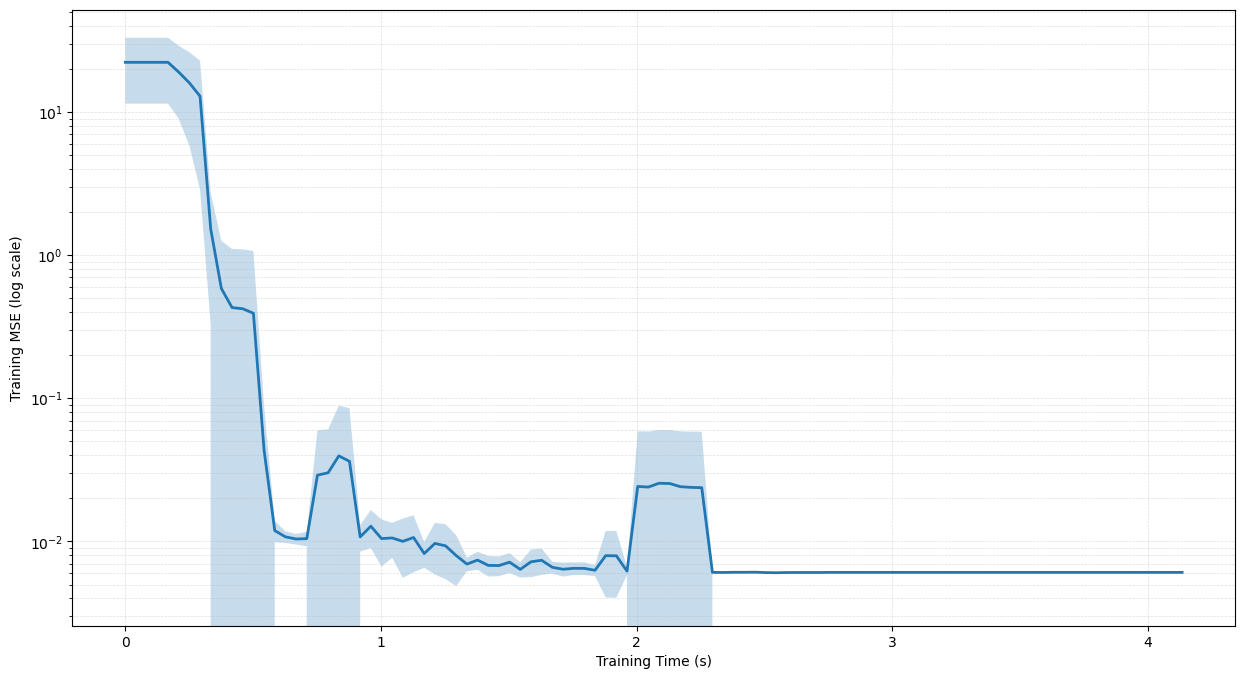

In [86]:
plt.figure(figsize=(15,8))
plot_convergence_ci(x_grid, mean, lo, hi, label="Pyomo")

<Axes: xlabel='Training Time (s)', ylabel='Training MSE (log scale)'>

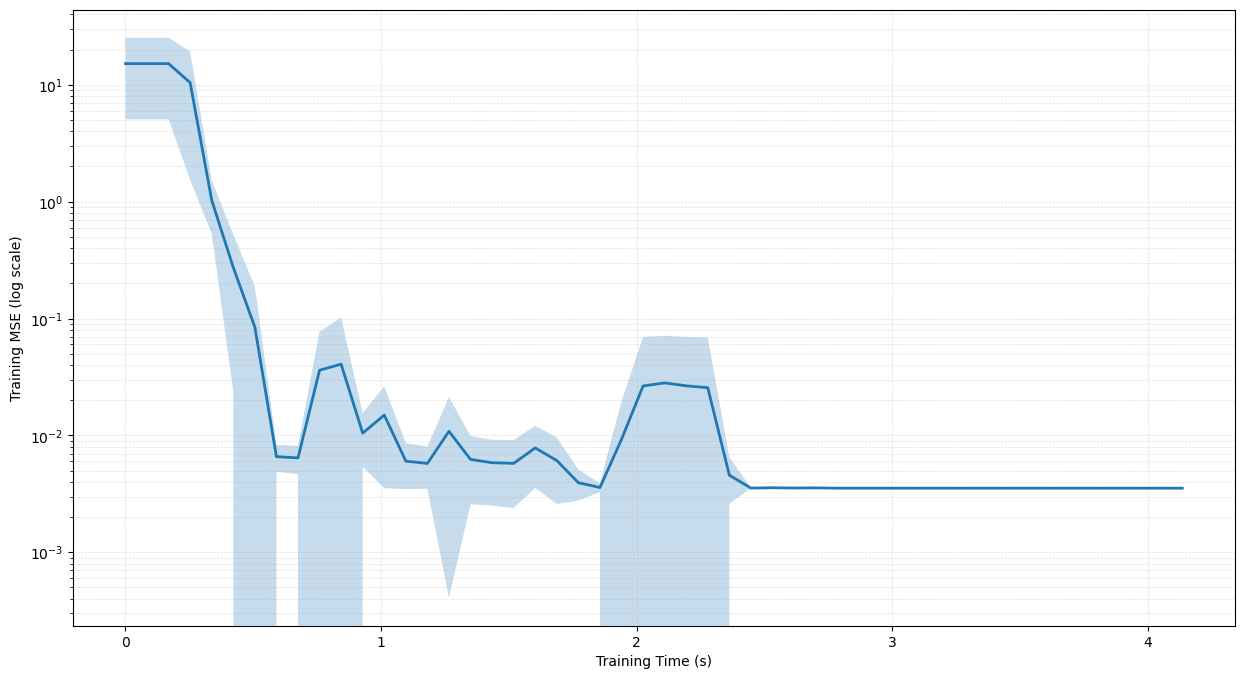

In [87]:
x_grid, mean, lo, hi, Y = ConvergenceCI.time_ci(results_df, system = "ho", pretrain=True, ci = "t", grid_points=50, y_col="mse_test")
plt.figure(figsize=(15,8))
plot_convergence_ci(x_grid, mean, lo, hi, label="Pyomo")